In [1]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt

# Random generator for reproducibility
rng = np.random.default_rng(42)


In [2]:
# Cell 2: Generate synthetic LIG dataset
n_samples = 50  # number of LIG samples

# Feature 1: Laser fluence (J/cm²)
fluence = rng.uniform(1.5, 4.0, n_samples)

# Feature 2: ID/IG ratio (negatively correlated with fluence)
ID_IG = 1.2 - 0.15*fluence + rng.normal(0, 0.03, n_samples)

# Feature 3: Sheet resistance (Ohm/sq, partially correlated with ID/IG)
sheet_resistance = 40 + 25*ID_IG + rng.normal(0, 2, n_samples)

# Stack features into a matrix (each column is a feature)
X = np.vstack((fluence, ID_IG, sheet_resistance)).T

print("Shape of data matrix X:", X.shape)


Shape of data matrix X: (50, 3)


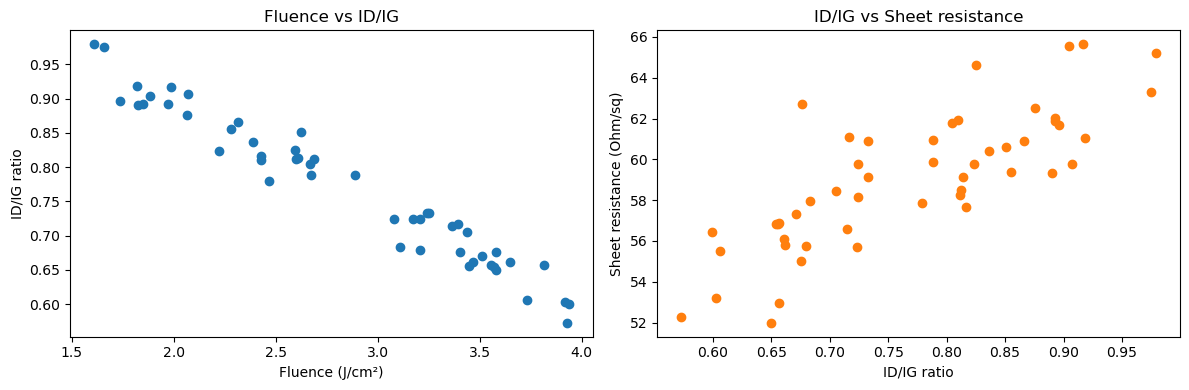

In [3]:
# Cell 3: Scatter plot to see relationships
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(fluence, ID_IG, color='C0')
plt.xlabel("Fluence (J/cm²)")
plt.ylabel("ID/IG ratio")
plt.title("Fluence vs ID/IG")

plt.subplot(1,2,2)
plt.scatter(ID_IG, sheet_resistance, color='C1')
plt.xlabel("ID/IG ratio")
plt.ylabel("Sheet resistance (Ohm/sq)")
plt.title("ID/IG vs Sheet resistance")

plt.tight_layout()
plt.show()


In [4]:
# Cell 4: Covariance manual calculation between Fluence and ID/IG
mean_fluence = np.mean(fluence)
mean_ID_IG = np.mean(ID_IG)

cov_fluence_IDIG = 1/(n_samples-1) * (fluence - mean_fluence).dot(ID_IG - mean_ID_IG)
print(f"Covariance (Fluence, ID/IG) = {cov_fluence_IDIG:.4f}")


Covariance (Fluence, ID/IG) = -0.0731


In [5]:
# Cell 5: Covariance matrix using NumPy
cov_matrix = np.cov(X, rowvar=False)
print("Covariance matrix:\n", cov_matrix)


Covariance matrix:
 [[ 0.49230933 -0.07313298 -1.75277988]
 [-0.07313298  0.01139063  0.28174395]
 [-1.75277988  0.28174395 10.96630309]]


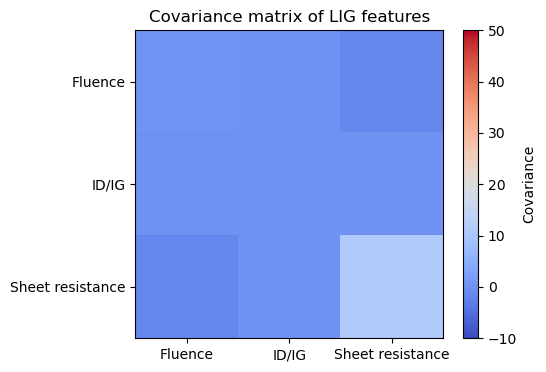

In [6]:
# Cell 6: Heatmap of covariance matrix
plt.figure(figsize=(5,4))
im = plt.imshow(cov_matrix, cmap='coolwarm', vmin=-10, vmax=50)
plt.colorbar(im, label="Covariance")
plt.xticks([0,1,2], ["Fluence","ID/IG","Sheet resistance"])
plt.yticks([0,1,2], ["Fluence","ID/IG","Sheet resistance"])
plt.title("Covariance matrix of LIG features")
plt.show()
